# UC2 · 04 — Interoperability and a temporal downstream task

The same object hands itself to igraph, Cytoscape and PyTorch-Geometric, keeps
a replayable record of how it was built, and backs a forecasting task that uses
the `time` aspect directly. Nothing here re-reads a source file: everything
comes out of `data/uc2.annnet`.

In [1]:
import random
import time
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, roc_auc_score
from torch_geometric.nn import SAGEConv

import annnet as an

DATA, OUT = Path("data"), Path("outputs")
TABLES, FIGS = OUT / "tables", OUT / "figures"
SNAPSHOT = DATA / "uc2.annnet"

SEED = 7
INPUT_TIMES = ("1h", "12h", "24h", "48h", "72h")
TARGET_TIME = "96h"
HIDDEN, LR, EPOCHS, N_SEEDS, TEST_FRAC = 64, 1e-2, 60, 3, 0.30

G = an.AnnNet.read(str(SNAPSHOT))

edge_kind = G.attrs.get_attr_from_edges("edge_kind")
E = pd.DataFrame(
    [(e, s[0], *s[1], t[0], *t[1], edge_kind[e]) for e, (s, t, _) in G.edge_definitions.items()],
    columns=["edge_id", "src", "src_mech", "src_time", "tgt", "tgt_mech", "tgt_time", "edge_kind"],
)
print(f"reloaded {G.ncount():,} nodes, {G.ecount():,} edges")

/home/l1boll/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


reloaded 19,587 vertices, 63,891 edges


## 4.1 Backend swap — Leiden in igraph

`G.ig.backend()` converts the whole graph once and caches it. Inducing on
`edge_kind='signaling'` inside igraph collects the signaling edges from *all*
time layers into one network — a signaling edge is a signaling edge whichever
timepoint holds it. Leiden then runs in C and the cluster ids are written
straight back onto the same AnnNet object.

The conversion is lossy in two documented ways, and warns about both:
hyperedges are dropped and the slices are flattened. The `.annnet` snapshot in
4.6, not this view, is what round-trips.

It also does not fix a node order, and Leiden is order-sensitive, so the
community *count* moves by a few percent between runs while the modularity
stays put. The stable number is the one to quote.

In [2]:
t0 = time.perf_counter()
ig_full = G.ig.backend()
ig_sig = ig_full.subgraph_edges(ig_full.es.select(edge_kind="signaling"), delete_vertices=True)
convert = time.perf_counter() - t0

t0 = time.perf_counter()
random.seed(SEED)  # pins igraph's RNG; vertex order is the remaining source of variation
undirected = ig_sig.as_undirected()
partition = undirected.community_leiden(objective_function="modularity", n_iterations=5)
print(f"AnnNet -> igraph, induce signaling : {convert:.2f}s (|V|={ig_sig.vcount():,} |E|={ig_sig.ecount():,})")
print(f"Leiden                             : {time.perf_counter() - t0:.2f}s -> {len(partition):,}"
      f" communities, modularity {undirected.modularity(partition.membership):.3f}")

# igraph keeps one vertex per supra-node and carries its key as the vertex name, so a
# protein responding at four timepoints is clustered four times. AnnNet stores one
# attribute record per node_id, so each protein takes its modal community.
per_protein = {}
for (vid, _), c in zip(ig_sig.vs["name"], partition.membership):
    per_protein.setdefault(vid, Counter())[int(c)] += 1
community = {v: counts.most_common(1)[0][0] for v, counts in per_protein.items()}

G.attrs.set_node_attrs_bulk({v: {"leiden_community": c} for v, c in community.items()})
G.history.snapshot("after_backend_swap")
split = sum(len(c) > 1 for c in per_protein.values())
print(f"{len(community):,} proteins from {ig_sig.vcount():,} supra-nodes"
      f" ({split:,} split across more than one community)")
print("largest communities:", Counter(community.values()).most_common(5))

/mnt/c/Users/pc/desktop/annnet-remote/annnet/core/backend_accessors/_base.py:164: RuntimeWarning: AnnNet-igraph conversion is lossy: hyperedges dropped (hyperedge_mode='skip'); multiple slices flattened into single igraph graph.
  entry = dict(build())


AnnNet -> igraph, induce signaling : 1.59s (|V|=8,643 |E|=26,330)
Leiden                             : 0.04s -> 166 communities, modularity 0.755
3,489 proteins from 8,643 supra-nodes (2,159 split across more than one community)
largest communities: [(1, 1072), (5, 675), (4, 585), (3, 413), (7, 241)]


## 4.2 Provenance — snapshot diff

Each build stage in `01` called `G.history.snapshot(label)`. `history.diff`
returns the structural delta between any two, so the build reconstructs after
the fact without re-running it.

In [3]:
labels = list(dict.fromkeys(s["label"] for s in G.history.list_snapshots()))
diffs = pd.DataFrame(
    [
        {
            "from": a,
            "to": b,
            "nodes_added": len(d["nodes_added"]),
            "edges_added": len(d["edges_added"]),
            "slices_added": len(d["slices_added"]),
        }
        for a, b in zip(labels, labels[1:])
        for d in [G.history.diff(a, b).to_dict()]
    ]
)
diffs.to_csv(TABLES / "history_diffs.csv", index=False)
print(diffs.to_string(index=False))

                  from                     to  vertices_added  edges_added  slices_added
                  init         after_response            5615        36492             0
        after_response         after_coupling               0        10982             0
        after_coupling          after_complex            5517         3446             0
         after_complex        after_metabolic            8455        12971            10
       after_metabolic after_organelle_slices               0            0             9
after_organelle_slices     after_backend_swap               0            0             0


## 4.3 CX2 export for Cytoscape

Cytoscape has no hyperedge primitive, so the export takes a policy: `'skip'`
drops them, `'reify'` turns each into a node joined to its members, `'expand'`
replaces it with a clique. The full graph is too large to draw in a notebook,
so the inline preview below reifies four complexes — one node per complex,
joined to its subunits.

In [9]:
G.layers.list_layers()

{'mechanism': ['metabolic', 'regulatory', 'signaling'],
 'time': ['0h', '12h', '1h', '24h', '48h', '72h', '96h']}

In [12]:
cx2_path = OUT / "signaling.cx2"

cx2 = an.to_cx2(G, path=str(cx2_path), export_name="UC2 — time-resolved backbone", hyperedges="skip")
print(f"CX2 nodes: {len(cx2[4]['nodes'])} | {cx2_path.name} ({cx2_path.stat().st_size / 1e6:.1f} MB)")

# convert only the signaling subnetwork at 24h timepoint
cx2_pathb = OUT / "signaling-24h.cx2"
cx2b = an.to_cx2(G, path=str(cx2_pathb), export_name="UC2 — signaling 24h", layer = ('signaling','24h'),hyperedges="skip")
print(f"CX2 nodes (signaling, 24h): {len(cx2b[4]['nodes'])} | {cx2_pathb.name} ({cx2_pathb.stat().st_size / 1e6:.1f} MB)")

CX2 aspects: 7 | signaling.cx2 (18.3 MB)
CX2 aspects (signaling, 24h): 7 | signaling-24h.cx2 (0.7 MB)


In [5]:
sample = [(e, s) for e, s in G.hyperedge_definitions.items() if str(e).startswith("cpx:")][:4]
demo = an.AnnNet(directed=False)
demo.add_nodes(
    [{"node_id": p, "kind": "protein"} for p in sorted({m[0] for _, s in sample for m in s["members"]})]
)
demo.add_edges(
    [
        {"edge_id": e, "members": [m[0] for m in s["members"]], "edge_kind": "complex", "weight": 1.0}
        for e, s in sample
    ]
)
an.show_cx2(demo, hyperedges="reify", inline=True, export_name="Four complexes, reified")

## 4.4 PyG `HeteroData` export

`to_pyg` builds one node type per node `kind`. The typing comes from `kind`,
not the aspect coordinate, so this export flattens the time layers and skips
hyperedges — 4.5 builds its own time-aware view instead. The hyperedges stay in
`G`, in the CX2 file, and in the snapshot.

In [6]:
t0 = time.perf_counter()
hetero = an.to_pyg(G, hyperedge_mode="skip")
print(f"AnnNet -> PyG HeteroData : {time.perf_counter() - t0:.2f}s")
for node_type in hetero.node_types:
    print(f"  {node_type:<12s} n={hetero[node_type].num_nodes:,}")
for edge_type in hetero.edge_types:
    print(f"  {str(edge_type):<42s} m={hetero[edge_type].edge_index.size(1):,}")
torch.save(hetero, OUT / "heterodata.pt")

AnnNet -> PyG HeteroData : 0.36s
  protein      n=9,006
  gene         n=2,126
  metabolite   n=8,455
  ('protein', 'edge', 'protein')             m=30,950
  ('gene', 'edge', 'gene')                   m=13,202
  ('gene', 'edge', 'protein')                m=3,322


## 4.5 Next-step response forecasting

The task the `time` aspect makes natural: **given only the graph up to 72h,
forecast which genes join the response at 96h.** Candidates are the genes
appearing in the regulatory layers at 1h–72h; positives are those responsive at
96h but not at 72h. No 96h layer and no 96h attribute enters the graph or the
features, so the target cannot leak.

Message passing runs over the real supra-nodes `(entity, mechanism, t)` for
t ≤ 72h — the multilayer structure *is* the computation graph.

In [7]:
FAMILIES = ("signaling", "regulatory", "coupling_time", "coupling_translation")

node_index, family_edges = {}, {k: [] for k in FAMILIES}
for r in E[E.edge_kind.isin(FAMILIES)].itertuples():
    if r.src_time not in INPUT_TIMES or r.tgt_time not in INPUT_TIMES:
        continue
    src = node_index.setdefault((r.src, r.src_mech, r.src_time), len(node_index))
    tgt = node_index.setdefault((r.tgt, r.tgt_mech, r.tgt_time), len(node_index))
    family_edges[r.edge_kind].append((src, tgt))

responsive = pl.read_parquet(DATA / "responsive.parquet").to_pandas()
responsive_at = {t: set(g["symbol"]) for t, g in responsive.groupby("time", observed=True)}
logfc_at = {(r.symbol, r.time): r.best_logFC for r in responsive.itertuples()}
tf_symbols = set(
    pl.read_csv(DATA / "dorothea.tsv", separator="\t", infer_schema_length=5000)["source_genesymbol"]
)
position = {t: i / (len(INPUT_TIMES) - 1) for i, t in enumerate(INPUT_TIMES)}

features = torch.tensor(
    [
        [
            float(mechanism == "signaling"),
            float(mechanism == "regulatory"),
            position[t],
            float(vid.split(":", 1)[1] in tf_symbols),
            float(logfc_at.get((vid.split(":", 1)[1], t), 0.0)),
        ]
        for vid, mechanism, t in node_index
    ],
    dtype=torch.float32,
)

# Each candidate gene is read out at its latest regulatory supra-node <= 72h.
latest = {}
for (vid, mechanism, t), i in node_index.items():
    symbol = vid.removeprefix("gene:")
    if mechanism == "regulatory" and (symbol not in latest or position[t] > position[latest[symbol][1]]):
        latest[symbol] = (i, t)

candidates = sorted(latest)
y = np.array(
    [int(s in responsive_at[TARGET_TIME] and s not in responsive_at[INPUT_TIMES[-1]]) for s in candidates]
)
readout = torch.tensor([latest[s][0] for s in candidates], dtype=torch.long)

print(f"supra-nodes {len(node_index):,} | candidate genes {len(candidates):,}")
print(f"{TARGET_TIME}-specific positives: {y.sum()} ({y.mean():.1%} base rate)")
print("edge families:", {k: len(v) for k, v in family_edges.items()})

supra-nodes 9,322 | candidate genes 1,543
96h-specific positives: 108 (7.0% base rate)
edge families: {'signaling': 15410, 'regulatory': 6570, 'coupling_time': 4841, 'coupling_translation': 2139}


### Model and evaluation

Everything a run reads travels in a frozen `Forecast`, so a configuration is a
choice of edge families rather than a mutated global.

In [8]:
UNDIRECTED = {"signaling", "regulatory", "coupling_translation"}  # time-coupling stays forward


@dataclass(frozen=True)
class Forecast:
    features: torch.Tensor
    family_edges: dict
    readout: torch.Tensor
    y: np.ndarray
    train_idx: np.ndarray
    test_idx: np.ndarray


shuffled = np.random.default_rng(SEED).permutation(len(candidates))
split = int(TEST_FRAC * len(candidates))
forecast = Forecast(features, family_edges, readout, y, shuffled[split:], shuffled[:split])


def edge_index(task, families):
    """(2, m) index over the chosen families, with reverse edges for the undirected ones."""
    forward = [e for k in families for e in task.family_edges[k]]
    index = torch.tensor(forward, dtype=torch.long).t().contiguous()
    reverse = [e for k in families if k in UNDIRECTED for e in task.family_edges[k]]
    if reverse:
        index = torch.cat([index, torch.tensor(reverse, dtype=torch.long).t().flip(0)], dim=1)
    return index


class Forecaster(torch.nn.Module):
    def __init__(self, in_dim, hidden):
        super().__init__()
        self.conv1, self.conv2 = SAGEConv(in_dim, hidden), SAGEConv(hidden, hidden)
        self.head = torch.nn.Linear(hidden, 1)

    def forward(self, x, index):
        return self.head(self.conv2(self.conv1(x, index).relu(), index).relu()).squeeze(-1)


def train_eval(task, families, seed):
    """Train on the given edge families; return held-out AUROC and average precision."""
    torch.manual_seed(seed)
    index = edge_index(task, families)
    target = torch.tensor(task.y, dtype=torch.float32)
    model = Forecaster(task.features.size(1), HIDDEN)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    for _ in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        logits = model(task.features, index)[task.readout[task.train_idx]]
        F.binary_cross_entropy_with_logits(logits, target[task.train_idx]).backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(task.features, index)[task.readout[task.test_idx]]).numpy()
    return roc_auc_score(task.y[task.test_idx], p), average_precision_score(task.y[task.test_idx], p)

### Channel ablation

Note what the second row must do: the candidates are regulatory supra-nodes,
and without translation coupling no path connects them to the protein
supra-nodes, so adding signaling alone attaches a disconnected component and
cannot move the scores. The ablation only starts moving once coupling bridges
the two mechanisms — which is the multilayer claim, stated as a measurement.

features + regulatory    AUROC=0.922 +/- 0.006  AP=0.299


+ signaling              AUROC=0.922 +/- 0.006  AP=0.299


+ translation            AUROC=0.934 +/- 0.015  AP=0.367


+ time-coupling          AUROC=0.928 +/- 0.010  AP=0.376

base rate 0.070 | AUROC 0.922 -> 0.934 | AP 0.299 -> 0.376


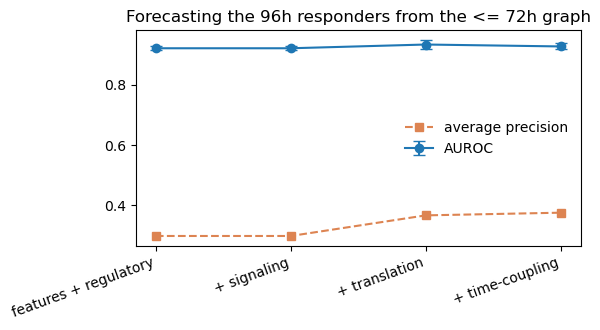

In [9]:
CONFIGS = [
    ("features + regulatory", ["regulatory"]),
    ("+ signaling", ["regulatory", "signaling"]),
    ("+ translation", ["regulatory", "signaling", "coupling_translation"]),
    ("+ time-coupling", ["regulatory", "signaling", "coupling_translation", "coupling_time"]),
]

rows = []
for tag, families in CONFIGS:
    results = [train_eval(forecast, families, seed=SEED + s) for s in range(N_SEEDS)]
    auroc, ap = np.array([r[0] for r in results]), np.array([r[1] for r in results])
    rows.append({"config": tag, "auroc": auroc.mean(), "auroc_std": auroc.std(), "ap": ap.mean()})
    print(f"{tag:<24s} AUROC={auroc.mean():.3f} +/- {auroc.std():.3f}  AP={ap.mean():.3f}")

ablation = pd.DataFrame(rows)
ablation.to_csv(TABLES / "gnn_forecast_ablation.csv", index=False)
print(f"\nbase rate {y.mean():.3f} | AUROC {ablation.auroc.iloc[0]:.3f} -> {ablation.auroc.max():.3f}"
      f" | AP {ablation.ap.iloc[0]:.3f} -> {ablation.ap.max():.3f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.errorbar(range(len(ablation)), ablation.auroc, yerr=ablation.auroc_std, marker="o", capsize=4, label="AUROC")
ax.plot(range(len(ablation)), ablation.ap, "s--", color="#dd8452", label="average precision")
ax.set_xticks(range(len(ablation)))
ax.set_xticklabels(ablation.config, rotation=20, ha="right")
ax.set_title(f"Forecasting the {TARGET_TIME} responders from the <= 72h graph")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGS / "gnn_forecast_ablation.png", dpi=150)
plt.show()

## 4.6 Round-trip

One `.annnet` file carries both aspects, both hyperedge families, the slices,
the coupling, every attribute table added along the way — including the Leiden
ids written in 4.1 — and the history.

In [10]:
G.history.snapshot("final")
G.write(str(SNAPSHOT), overwrite=True)
reloaded = an.AnnNet.read(str(SNAPSHOT))
print(f"{SNAPSHOT.name} ({SNAPSHOT.stat().st_size / 1e6:.1f} MB)")
print(f"|V|={reloaded.ncount():,} |E|={reloaded.ecount():,}"
      f" aspects={reloaded.layers.list_aspects()} slices={len(reloaded.slices.list()):,}")
print(f"leiden ids survived: {reloaded.views.nodes().to_pandas().leiden_community.notna().sum():,}")

uc2.annnet (6.7 MB)
|V|=19,587 |E|=63,891 aspects=('mechanism', 'time') slices=20
leiden ids survived: 3,489


## Scope

This is a software case study. Fixed seeds, cached inputs and deterministic
ordering make the build reproducible. No result here claims that a forecast
gene is a real regulator or that a query output is a finding about kidney
fibrosis — the biology is a substrate for exercising one heterogeneous,
time-resolved container.

Two design choices are worth stating because they were not free. The
**0-hop responsive restriction** — a node-layer exists only where the entity is
differential, an intra-layer edge only where both endpoints are — was chosen
over seed + 1-hop expansion, which over-densified until consecutive layers were
near-identical and the time aspect carried no structure. And because AnnNet
keeps one attribute record per `node_id`, per-timepoint values cannot live on
the node; they stay in `responsive.parquet`, while the graph carries the time
signal in layer membership and edge coordinates.